In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load the data
train_data = pd.read_csv('dataset/train.csv')
test_data = pd.read_csv('dataset/test.csv')

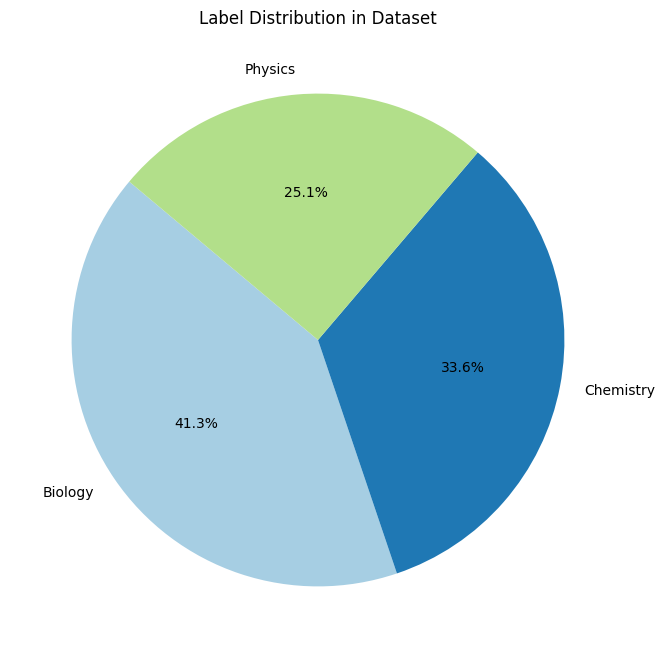

In [40]:
label_counts = train_data['label'].value_counts()
label_names = [id_to_label[label_id] for label_id in label_counts.index]  # Convert label IDs to names

# Plot a pie chart
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_names, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Label Distribution in Dataset")
plt.show()

In [ ]:
# Text Preprocessing Function (simplified for BERT)
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Preprocess comments
train_data['processed_comment'] = train_data['Comment'].apply(preprocess_text)
test_data['processed_comment'] = test_data['Comment'].apply(preprocess_text)

In [ ]:
# TF-IDF Vectorizer Setup
tfidf = TfidfVectorizer(max_features=5000)
tfidf.fit(train_data['processed_comment'])
train_tfidf = tfidf.transform(train_data['processed_comment'])
test_tfidf = tfidf.transform(test_data['processed_comment'])

# Convert labels to IDs
label_to_id = {label: idx for idx, label in enumerate(train_data['Topic'].unique())}
id_to_label = {idx: label for label, idx in label_to_id.items()}
train_data['label'] = train_data['Topic'].map(label_to_id)
test_data['label'] = test_data['Topic'].map(label_to_id)

In [ ]:
# Dataset Class for PyTorch with TF-IDF Integration
class CommentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, tfidf_matrix, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.tfidf_matrix = tfidf_matrix
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        tfidf_vector = torch.tensor(self.tfidf_matrix[idx].toarray(), dtype=torch.float32).squeeze()
        inputs = self.tokenizer(
            text, truncation=True, padding="max_length", max_length=self.max_length, return_tensors="pt"
        )
        input_ids = inputs["input_ids"].squeeze()
        attention_mask = inputs["attention_mask"].squeeze()
        label = torch.tensor(self.labels[idx])
        return input_ids, attention_mask, tfidf_vector, label

# BERT-based Classification Model with TF-IDF Integration
class BERTClassifier(nn.Module):
    def __init__(self, num_classes, tfidf_dim):
        super(BERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(self.bert.config.hidden_size + tfidf_dim, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask, tfidf_vector):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        combined = torch.cat((pooled_output, tfidf_vector), dim=1)
        dropout_output = self.dropout(combined)
        logits = self.fc2(self.fc1(dropout_output))
        return logits

In [ ]:
# Tokenizer and Data Preparation
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
train_dataset = CommentDataset(train_data['processed_comment'].tolist(), train_data['label'].tolist(), tokenizer, train_tfidf)
test_dataset = CommentDataset(test_data['processed_comment'].tolist(), test_data['label'].tolist(), tokenizer, test_tfidf)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Model Initialization
model = BERTClassifier(num_classes=len(label_to_id), tfidf_dim=train_tfidf.shape[1])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training Setup
optimizer = optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Epoch 1, Loss: 0.7203690266337763
Epoch 2, Loss: 0.46125056610546367
Epoch 3, Loss: 0.28710262581754026


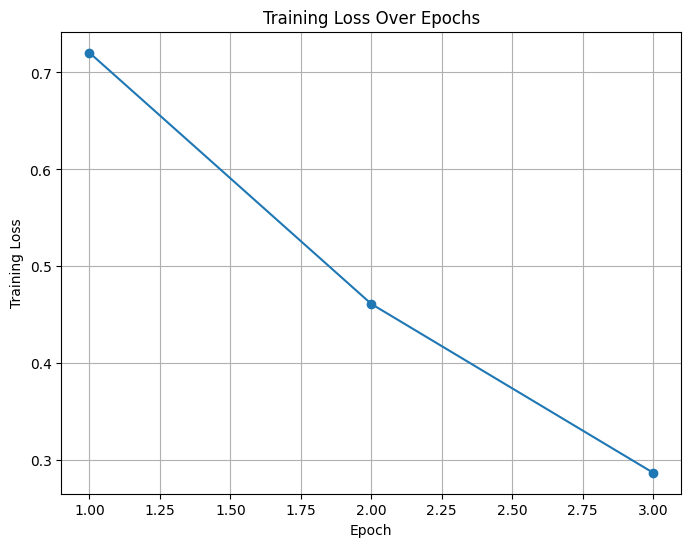

In [ ]:
# Training Loop
losses = []
for epoch in range(3):  # Train for 3 epochs
    model.train()
    total_loss = 0
    for input_ids, attention_mask, tfidf_vector, labels in train_loader:
        input_ids, attention_mask, tfidf_vector, labels = input_ids.to(device), attention_mask.to(device), tfidf_vector.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, tfidf_vector)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss / len(train_loader))
    print(f"Epoch {epoch + 1}, Loss: {total_loss / len(train_loader)}")

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(losses) + 1), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid()
plt.show()

In [ ]:
# Evaluation
model.eval()
predictions, true_labels = [], []
with torch.no_grad():
    for input_ids, attention_mask, tfidf_vector, labels in test_loader:
        input_ids, attention_mask, tfidf_vector = input_ids.to(device), attention_mask.to(device), tfidf_vector.to(device)
        outputs = model(input_ids, attention_mask, tfidf_vector)
        _, preds = torch.max(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Report Results
accuracy = accuracy_score(true_labels, predictions)
report = classification_report(true_labels, predictions, target_names=[id_to_label[i] for i in range(len(label_to_id))])
print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.8663303909205549
Classification Report:
               precision    recall  f1-score   support

     Biology       0.92      0.88      0.90       614
     Physics       0.82      0.92      0.87       466
   Chemistry       0.86      0.80      0.83       506

    accuracy                           0.87      1586
   macro avg       0.86      0.87      0.86      1586
weighted avg       0.87      0.87      0.87      1586



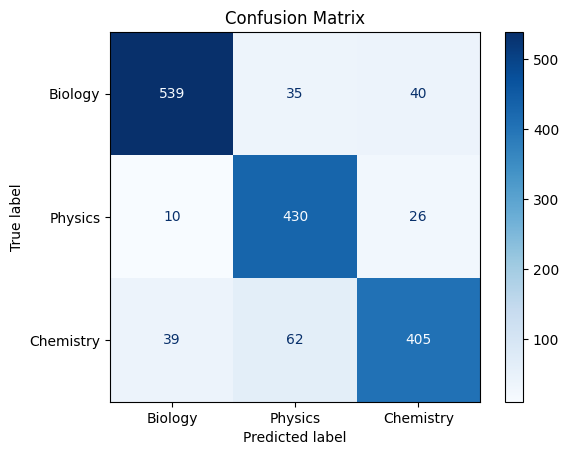

In [ ]:
# Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id_to_label[i] for i in range(len(label_to_id))])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [27]:
# Save the entire model
torch.save(model, 'bert_classifier_with_tfidf.pth')

In [32]:
# Load the entire model
model = torch.load('bert_classifier_with_tfidf.pth')
model.to(device)

<ipython-input-32-163a6a6c3c8b>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('bert_classifier_with_tfidf.pth')


BERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [37]:
# Plot the top TF-IDF terms as a bar chart
def plot_top_tfidf_terms(important_terms):
    terms, scores = zip(*important_terms)
    plt.figure(figsize=(10, 5))
    plt.barh(terms, scores, color='skyblue')
    plt.xlabel("TF-IDF Score")
    plt.title("Top TF-IDF Terms in Input Text")
    plt.gca().invert_yaxis()
    plt.show()

# Prediction Function with TF-IDF Terms
def predict_subject_with_tfidf(text):
    processed_text = preprocess_text(text)
    tfidf_vector = torch.tensor(tfidf.transform([processed_text]).toarray(), dtype=torch.float32).to(device)

    feature_names = tfidf.get_feature_names_out()

    important_terms = [(feature_names[i], tfidf_vector[0, i].cpu().item()) for i in tfidf_vector.nonzero(as_tuple=True)[1]]
    limit = 10 if len(important_terms) > 10 else len(important_terms)
    important_terms = sorted(important_terms, key=lambda x: x[1], reverse=True)[:10]  # Top 10 terms

    inputs = tokenizer(processed_text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        classification_logits = model(input_ids, attention_mask, tfidf_vector)

    predicted_class_id = classification_logits.argmax().item()
    predicted_topic = id_to_label[predicted_class_id]

    # Display TF-IDF term plot
    plot_top_tfidf_terms(important_terms)

    # Print the predicted subject
    print(f"\nPredicted Subject: {predicted_topic}")


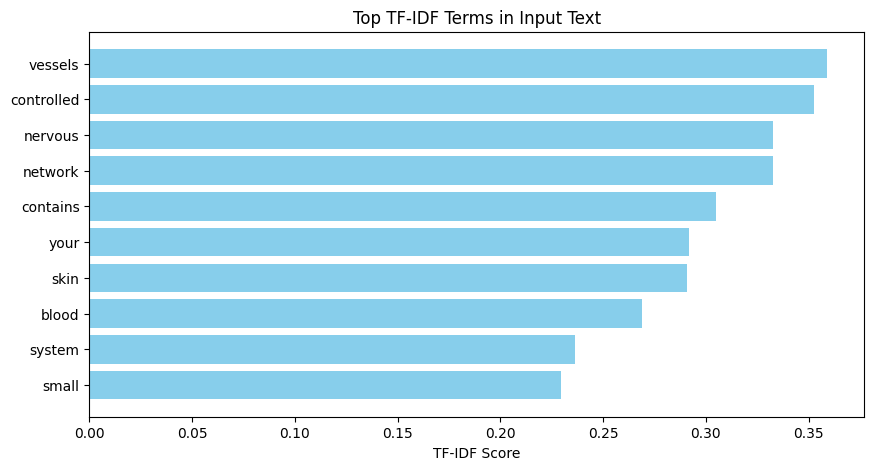


Predicted Subject: Biology


In [38]:
# Example 1
text = "Your skin contains a network of small blood vessels, which are controlled by your nervous system"
predict_subject_with_tfidf(text)

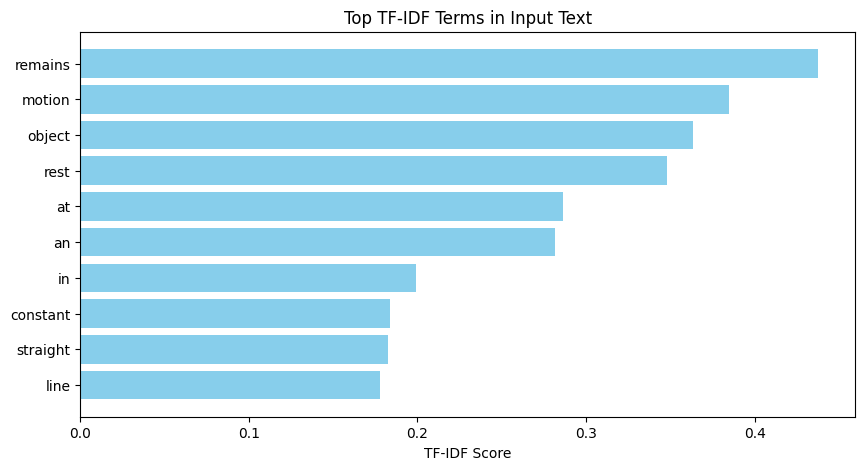


Predicted Subject: Physics


In [39]:
# Example 2
text = "An object at rest remains at rest, and an object in motion remains in motion at constant speed and in a straight line unless acted on by an unbalanced force"
predict_subject_with_tfidf(text)